## Example 2g:
Fusion of `example_2e` and `example_2f`, combining a flow-matched model and a set encoder with a dynamic stack geometry into one model. `example_2f` regressed in its posterior representational power by using a `CovarianceHead` in order to demonstrate the set encoder in isolation. This example remedies that, training a model that supports both arbitrary posterior shapes and arbitrary geometries (including both single-z images and stacks).

In [1]:
import logging
from pathlib import Path
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot
from matplotlib.lines import Line2D

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_velocity_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar, safe_load_from_checkpoint
from cynosure.zstack_decoding import ZstackSolver_FlowMatching
from cynosure.zstack_decoding.geometry_modes import UniformSpanGeometry
from cynosure.zstack_decoding.posterior_heads import get_default_set_encoder_spec

#### Simulation setup

In [4]:
use_pretrained = True  # enable to load weights from one of my checkpoints

train_cfg = get_default_training_config(learning_rate=1.0e-4)
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()
vel_cfg = get_default_velocity_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)
vel_cfg = get_default_velocity_config()

encoder_spec = get_default_set_encoder_spec(
    spatial_hidden_channels=(32, 64),
    image_embedding_dims=128,
    z_embedding_dims=128,
    num_attention_layers=2,
    num_attention_heads=2,
    attention_feedforward_dims=256,
)

geometry = UniformSpanGeometry(
    min_planes=1,
    max_planes=7,
    min_half_span=0.5,
    max_half_span=2.0,
)

In [5]:
rng_seed = 123
z_jitter = 1.0  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Train a model with stochastically-drawn stack geometries

In [6]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_FlowMatching(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    vel_cfg=vel_cfg,
    object_distribution=object_distrib,
    z_objective=geometry,
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
    encoder_spec=encoder_spec,
)
solver = solver.to(device)

Seed set to 123


In [7]:
checkpoint_path = Path("./pretrained_models/example_2g/checkpoints/final.ckpt")

if use_pretrained and checkpoint_path.is_file():
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=200,
        accelerator=device,
        log_every_n_steps=50,
        callbacks=[NoValidationBar()],
    )
    trainer.fit(solver)
    solver = solver.eval()

Sanity Checking: |                                                                   | 0/? [00:00<?, ?it/s]

Training: |                                                                          | 0/? [00:00<?, ?it/s]

#### Check the results

Each `create_examples` call draws a new stack geometry, with a random number and choice of z-positions. To see the variation, draw a few different size-1 batches separately, and plot the synthesized z-stacks vs. decoded and sampled images from each.

In [8]:
def generate_sample_plot(
        solver: ZstackSolver_FlowMatching,
        seed: int,
        num_samples: int,
        *,
        panel_size: float = 2.0
) -> pyplot.Figure:
    """
    Helper function that draws a batch of 1 example with a given RNG seed, predicts
    the aberrations, and plots a given number of samples from the predicted posteriors.
    """
    _ = pl.seed_everything(seed, workers=True)
    batch_size = 1

    solver = solver.eval()
    with torch.inference_mode():
        images, z, phase_coefs, amp_coefs = solver.simulator.create_examples(batch_size)
        pred_phase_coefs, pred_amp_coefs = solver.predict_samples(images, num_samples, z)
        pred_images = solver.simulator.simulate_normalized_stacks(
            pred_phase_coefs.reshape(batch_size*num_samples, -1),
            pred_amp_coefs.reshape(batch_size*num_samples, -1),
            z,
        ).unflatten(0, (batch_size, num_samples))  # [batch_size, num_samples, num_z, H, W]

    num_z = z.shape[-1]
    figsize = ((num_samples+1) * panel_size, num_z * panel_size)
    fig, axarr = pyplot.subplots(num_z, num_samples+1, figsize=figsize, squeeze=False)
    for iz in range(num_z):
        axarr[iz, 0].set_ylabel(f"Z = {float(z.squeeze(0)[iz]):.2f} um", size=11)
        axarr[0, 0].set_title("truth", size=11)
        axarr[iz, 0].imshow(images.squeeze(0)[iz].numpy(force=True))
        for isamp in range(num_samples):
            axarr[iz, isamp+1].imshow(pred_images.squeeze(0)[isamp, iz].numpy(force=True))
            axarr[0, isamp+1].set_title(f"sample {isamp}", size=11)

    for ax in axarr.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()
    return fig

Seed set to 124


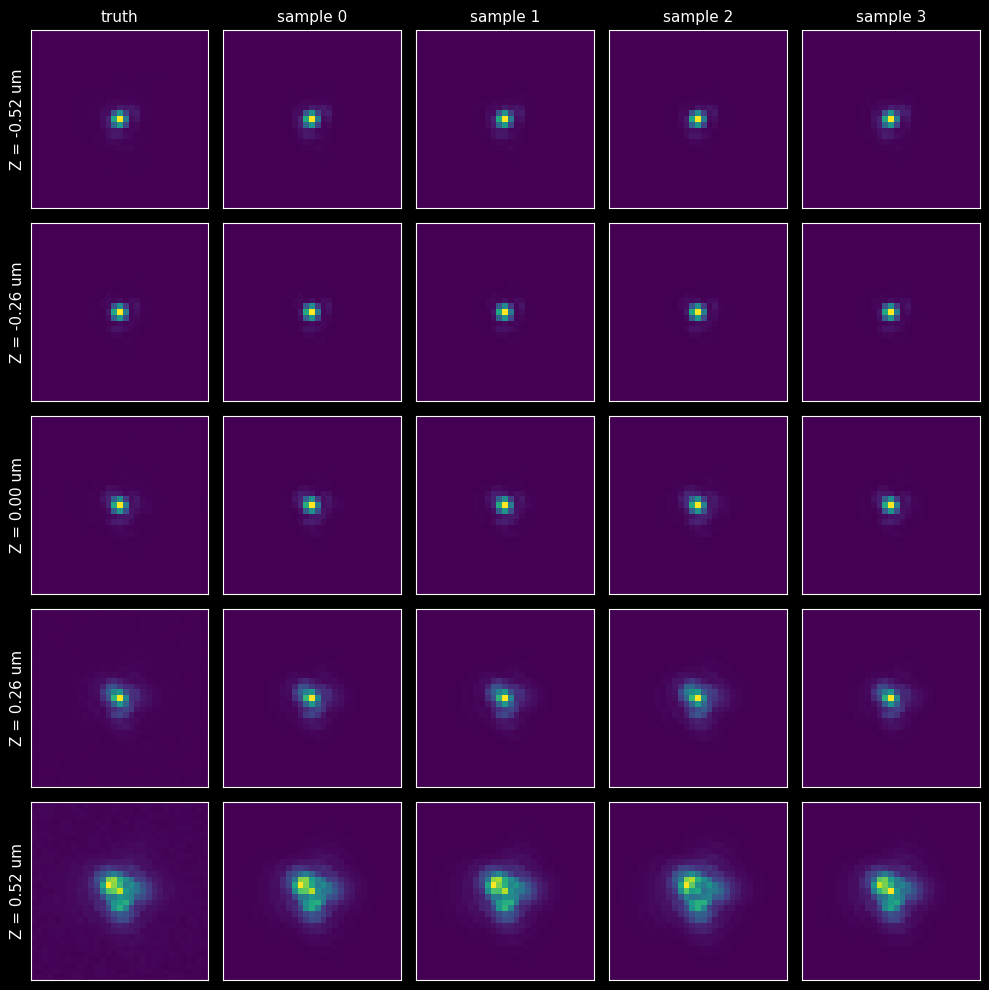

In [9]:
_ = generate_sample_plot(solver, rng_seed+1, 4)

Seed set to 125


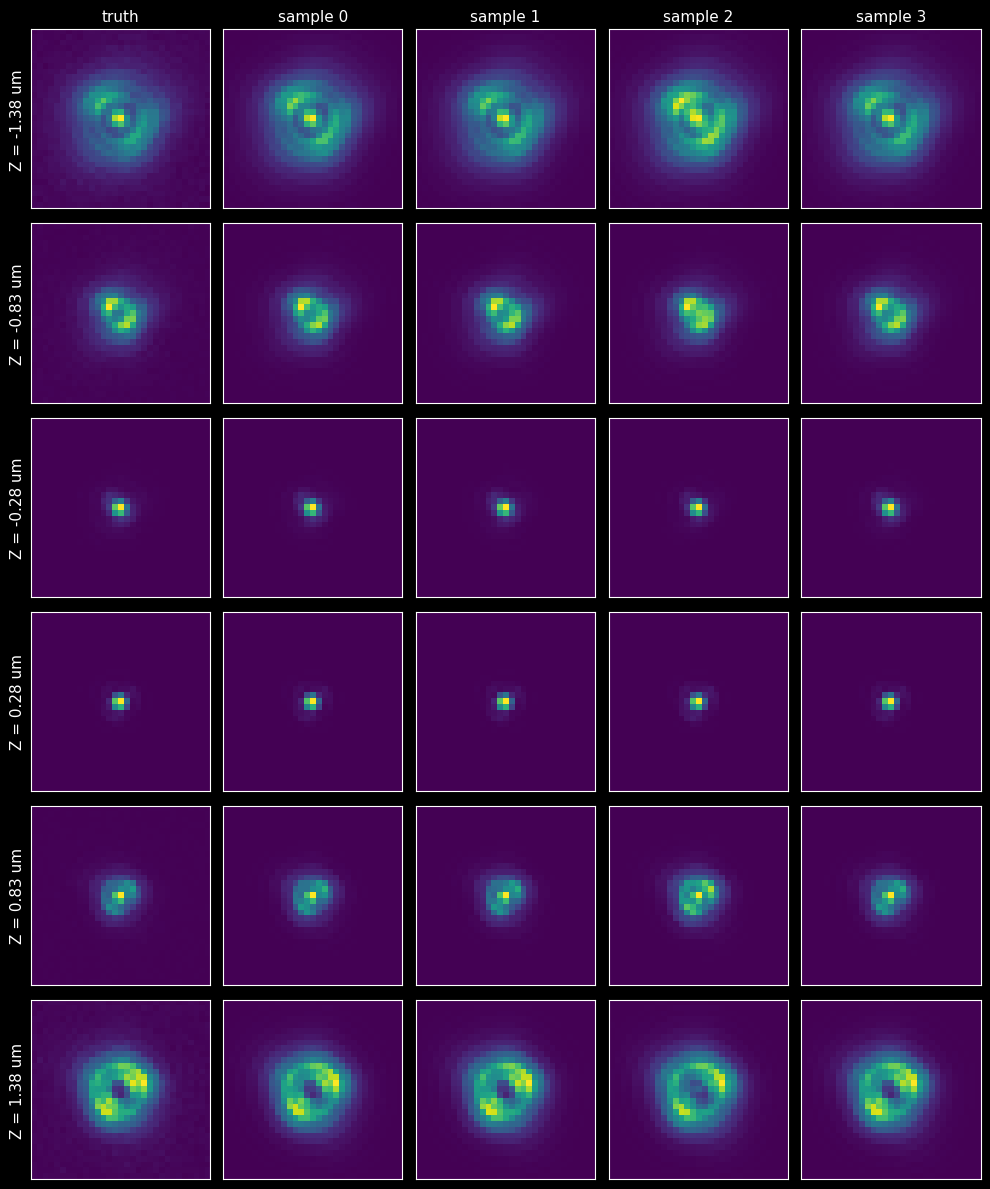

In [10]:
_ = generate_sample_plot(solver, rng_seed+2, 4)

Seed set to 126


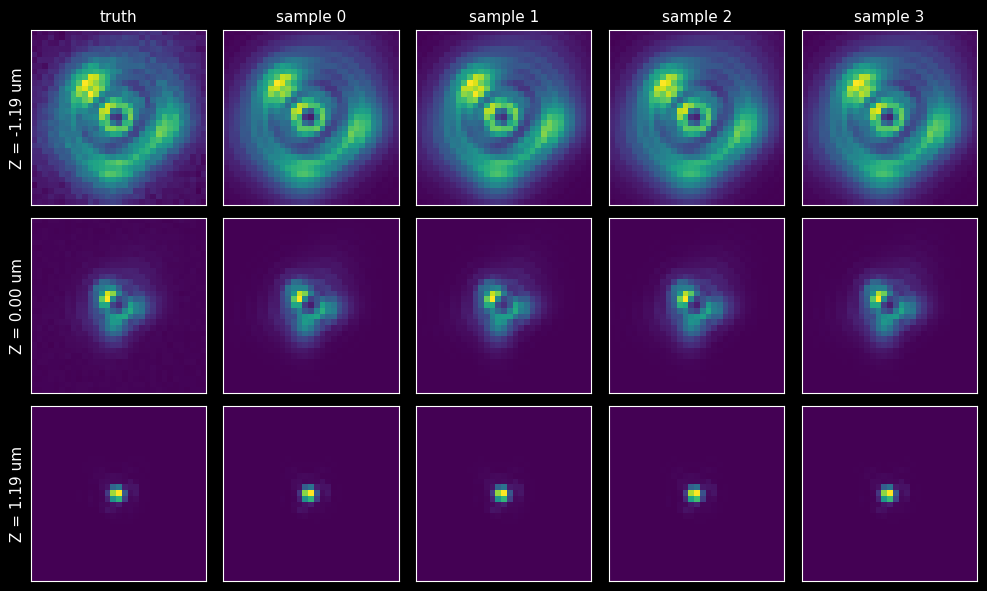

In [11]:
_ = generate_sample_plot(solver, rng_seed+3, 4)

Seed set to 127


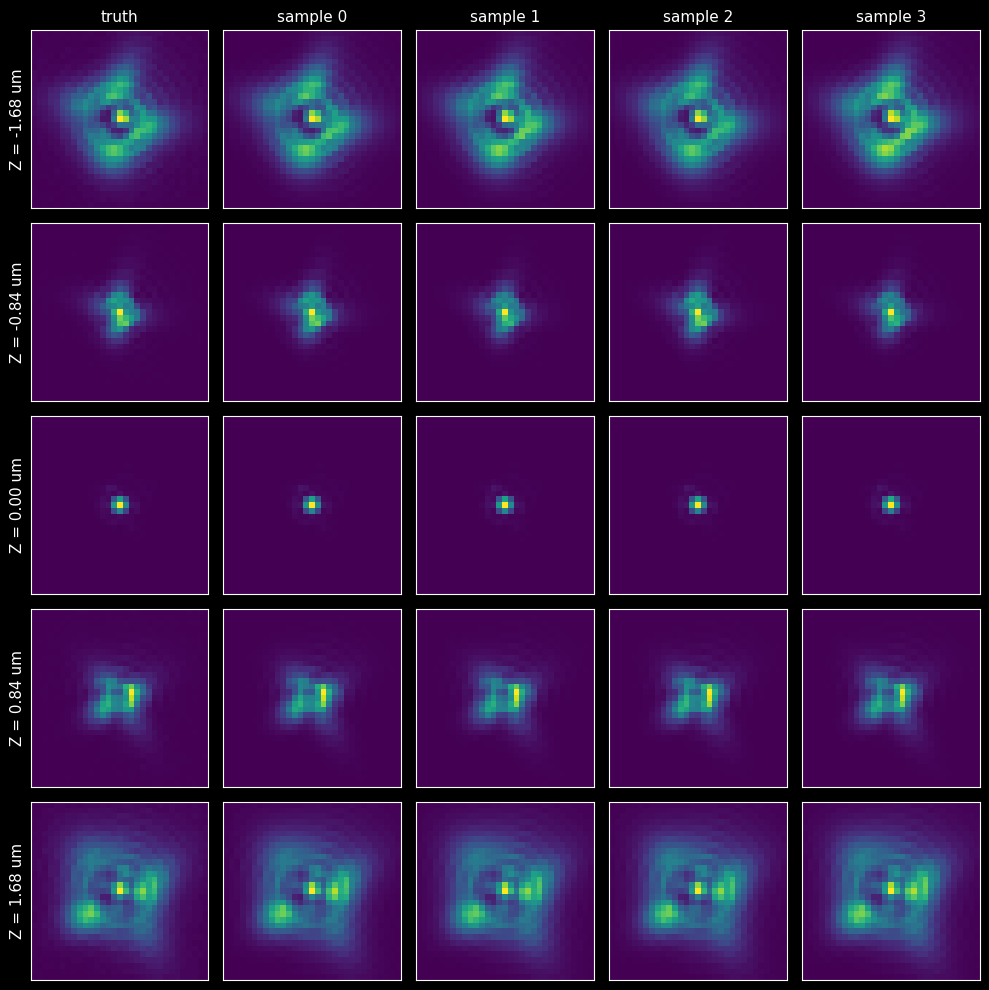

In [12]:
_ = generate_sample_plot(solver, rng_seed+4, 4)

Seed set to 128


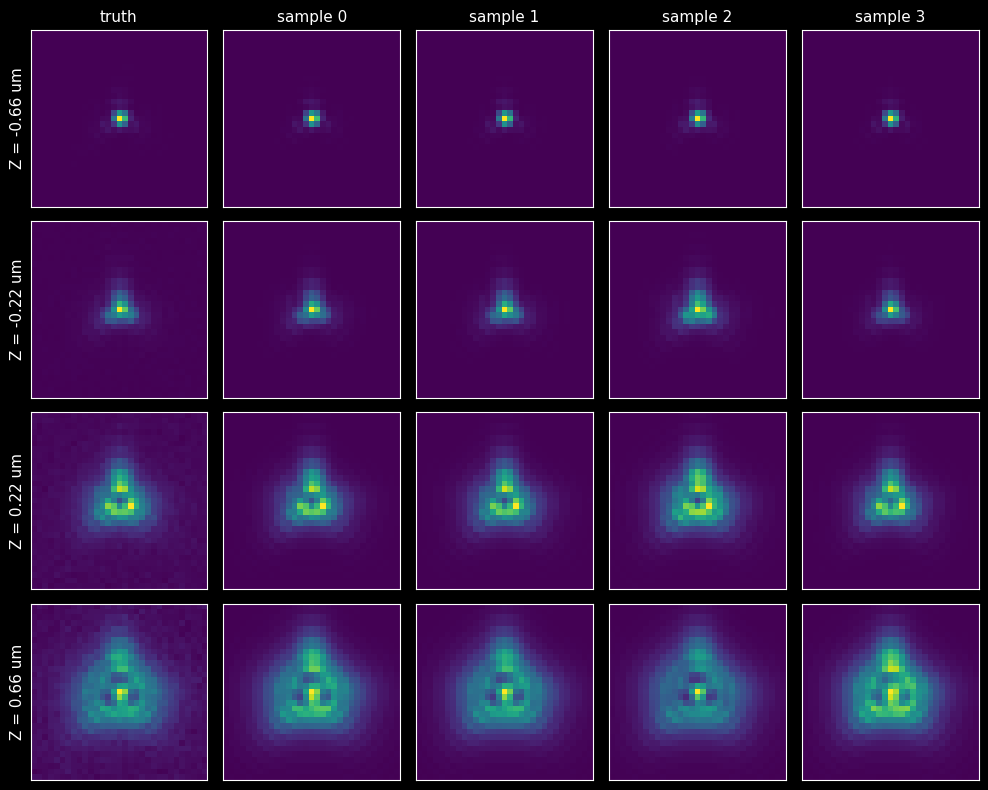

In [13]:
_ = generate_sample_plot(solver, rng_seed+5, 4)

Seed set to 129


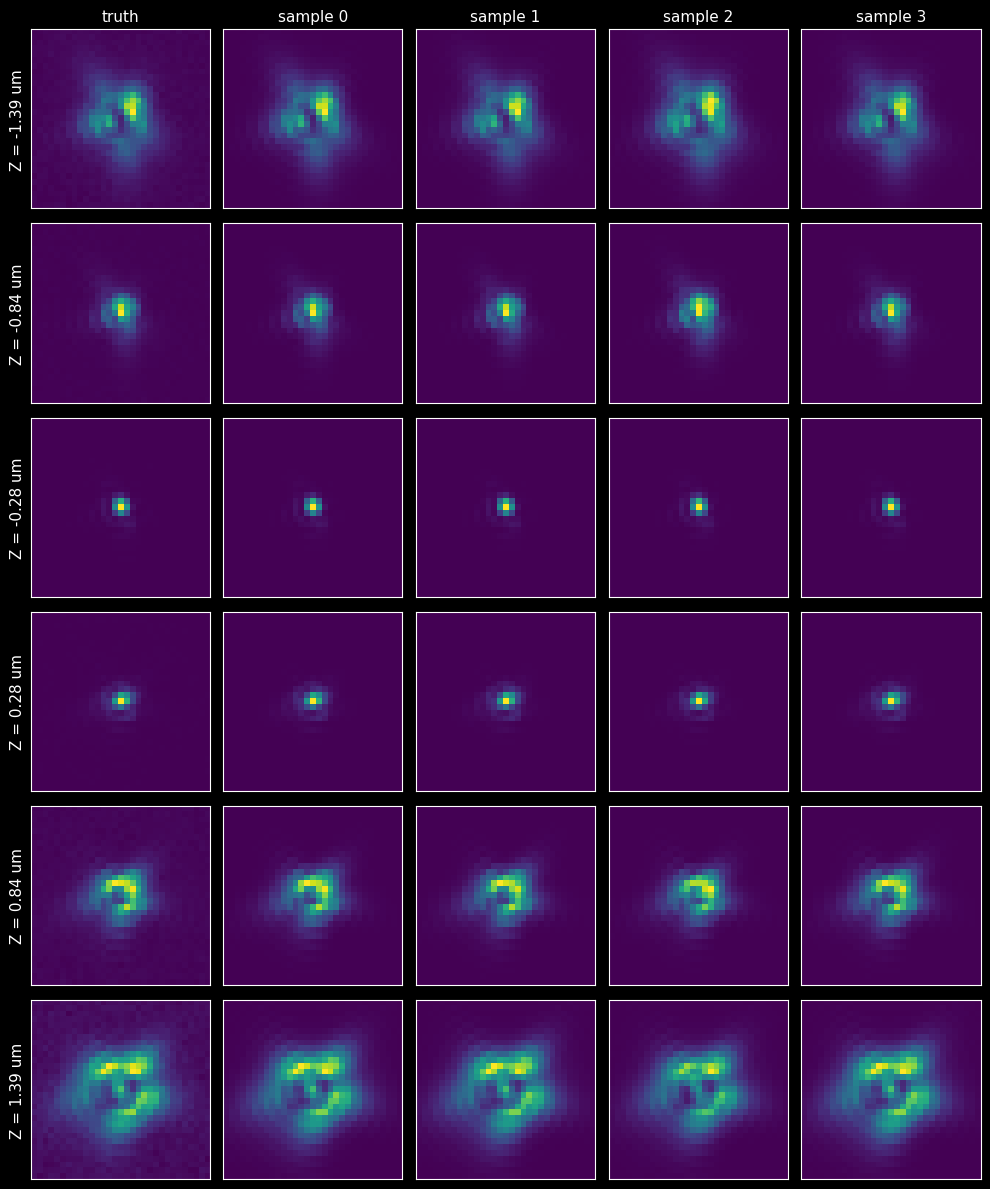

In [14]:
_ = generate_sample_plot(solver, rng_seed+6, 4)

Seed set to 130


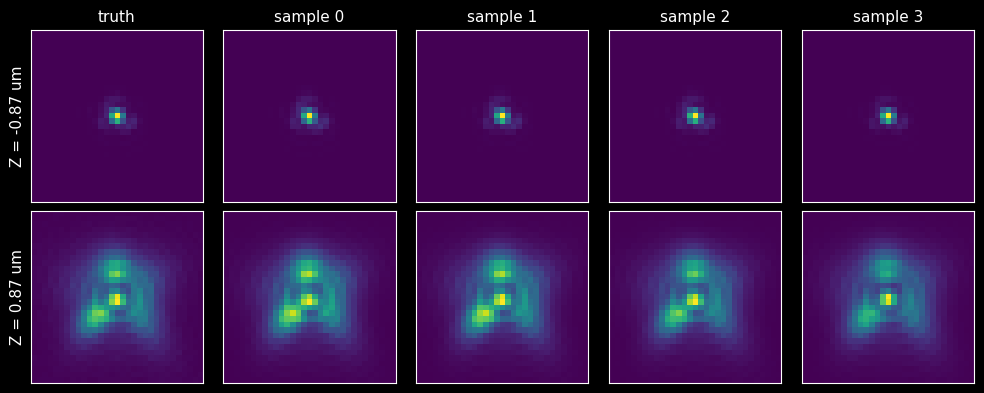

In [15]:
_ = generate_sample_plot(solver, rng_seed+7, 4)